In [75]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import string
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from phe import paillier

In [76]:
spamFolder1 = 'C:/Users/asus/Desktop/SpamData/enron1 (2)/enron1/spam'
spamFolder2 = 'C:/Users/asus/Desktop/SpamData/enron2 (1)/enron2/spam'

hamFolder1 = 'C:/Users/asus/Desktop/SpamData/enron1 (2)/enron1/ham'
hamFolder2 = 'C:/Users/asus/Desktop/SpamData/enron2 (1)/enron2/ham'


In [77]:
def custom_tokenizer(text):
    tokens = nltk.word_tokenize(text)

    tokens_lower = []
    for token in tokens:
        tokens_lower.append(token.lower())
    
    stop_words = set(stopwords.words('english'))
    punctuation = set(string.punctuation)

    filtered_elements = []
    for element in tokens_lower:
        if element not in stop_words and element not in punctuation and not element.isdigit():
            filtered_elements.append(element)
    return filtered_elements

Vectorizer with custom tokenizer and removing stopwords, punctuation and numerical values

In [78]:
def vectorizeData(spam_path, ham_path):
    spam_files = os.listdir(spam_path)
    ham_files = os.listdir(ham_path)
    
    vocabulary = []
    y = []
    for filenames in spam_files:
        sentence = ""
        cur_file = open(spam_path + "/" + filenames, errors='ignore')
        sentence = cur_file.read()
        vocabulary.append(sentence)
        y.append(1)
    
    for filenames in ham_files:
        sentence = ""
        cur_file = open(ham_path + "/" + filenames, errors='ignore')
        sentence = cur_file.read()
        vocabulary.append(sentence)
        y.append(0)

    vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer, min_df=0.1)
    X = vectorizer.fit_transform(vocabulary)
    feature_names = vectorizer.get_feature_names_out()
    return X, y, feature_names


X, y, feature_names = vectorizeData(spamFolder2, hamFolder2)
tfidf = pd.DataFrame(X.toarray(), columns=feature_names)
print(tfidf)
print(y)
    

C:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


            ''        ``      also  attached  available      back      best  \
0     0.000000  0.198893  0.000000  0.000000    0.00000  0.000000  0.000000   
1     0.000000  0.000000  0.000000  0.000000    0.00000  0.000000  0.000000   
2     0.000000  0.000000  0.107543  0.000000    0.00000  0.000000  0.116381   
3     0.000000  0.000000  0.000000  0.000000    0.00000  0.338438  0.286632   
4     0.059621  0.384370  0.048482  0.000000    0.00000  0.000000  0.087444   
...        ...       ...       ...       ...        ...       ...       ...   
5852  0.000000  0.551062  0.000000  0.000000    0.00000  0.000000  0.000000   
5853  0.000000  0.932442  0.062265  0.000000    0.00000  0.000000  0.067382   
5854  0.000000  0.295685  0.000000  0.000000    0.10157  0.000000  0.000000   
5855  0.000000  0.000000  0.000000  0.000000    0.00000  0.297687  0.000000   
5856  0.000000  0.173998  0.000000  0.121019    0.00000  0.126195  0.000000   

      business      call        cc  ...     vince  

In [79]:
X, y = shuffle(X, y, random_state=0)
tfidf2 = pd.DataFrame(X.toarray(), columns=feature_names)
print(tfidf2)
print(y)

       ''        ``     also  attached  available      back  best  business  \
0     0.0  0.000000  0.00000  0.000000   0.000000  0.000000   0.0  0.000000   
1     0.0  0.000000  0.00000  0.000000   0.000000  0.000000   0.0  0.000000   
2     0.0  0.000000  0.00000  0.000000   0.000000  0.000000   0.0  0.000000   
3     0.0  0.000000  0.12171  0.000000   0.000000  0.155518   0.0  0.000000   
4     0.0  0.000000  0.00000  0.000000   0.000000  0.264154   0.0  0.000000   
...   ...       ...      ...       ...        ...       ...   ...       ...   
5852  0.0  0.633221  0.00000  0.000000   0.096673  0.102057   0.0  0.000000   
5853  0.0  0.420744  0.00000  0.000000   0.000000  0.000000   0.0  0.000000   
5854  0.0  0.000000  0.00000  0.000000   0.000000  0.000000   0.0  0.000000   
5855  0.0  0.299318  0.00000  0.000000   0.000000  0.000000   0.0  0.000000   
5856  0.0  0.215696  0.00000  0.050007   0.000000  0.000000   0.0  0.044749   

          call        cc  ...     vince      want  

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [81]:
classifier = LogisticRegression()

In [82]:
classifier.fit(X_train, y_train)

LogisticRegression()

In [83]:
y_pred = classifier.predict(X_test)

In [84]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.9547781569965871


In [85]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)


[[843  29]
 [ 24 276]]


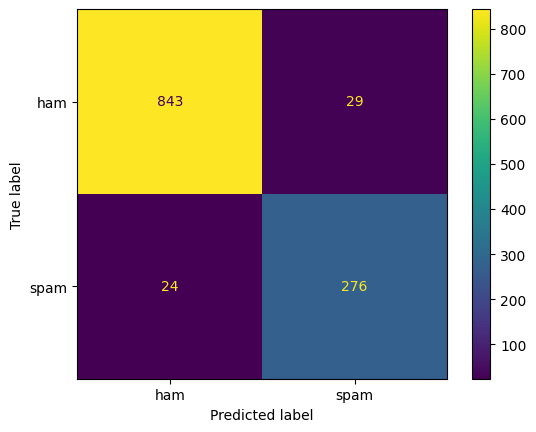

In [86]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ['ham', 'spam'])

cm_display.plot()
plt.show()

In [87]:
precision = precision_score(y_test,y_pred)
print(precision)

0.9049180327868852


In [88]:
class Server:
    def __init__(self):
        self.ml_model = LogisticRegression()

    def create_paillier_keypair(self):
        self.publickey, self.privatekey = paillier.generate_paillier_keypair()


    def predict(self, X):
        return self.ml_model.predict(X)

    def encrypt_params(self):
        model = LogisticRegression()
        coefficients = model.coef_[0,:]
        encrypted_weight = []
        for i in range(coefficients[0].shape):
            encrypted_weight.append(self.publickey.encrypt(coefficients[i]))

        encrypted_intercept = self.publickey.encrypt(model.intercept_)

    def decrypt_score(self, scores):
        output = []
        for element in scores:
            decrypted_score = self.privatekey.decrypt(element)
            threshold = 0.5
            if decrypted_score > threshold:
                output.append(1)
            else:
                output.append(0)

        return output


In [89]:
class Client:

    def __init__(self, public_key):
        self.public_key = public_key

    def encrypted_predict(self, weight, intercept, X):
        scores = []
        #iterating through each row of the data
        for i in range(X.shape[0]):
            score = intercept
            for j in range(X.shape[1]):
                score += X[i, j] * weight[j]
            scores.append(score)
        return scores


In [90]:
model = LogisticRegression()


In [91]:
X, y, feature_names = vectorizeData(spamFolder1, hamFolder1)
tfidf = pd.DataFrame(X.toarray(), columns=feature_names)
print(tfidf)
print(y)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

print("Server: Generating paillier keypair")
server = Server()
server.create_paillier_keypair()

print("Server: training the machine learning model")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


C:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


       ``      also  attached      call        cc      com      corp  \
0     0.0  0.511956  0.000000  0.000000  0.000000  0.00000  0.000000   
1     0.0  0.000000  0.000000  0.000000  0.000000  0.00000  0.000000   
2     0.0  0.000000  0.000000  0.000000  0.000000  0.00000  0.000000   
3     0.0  0.172340  0.000000  0.177260  0.000000  0.00000  0.000000   
4     0.0  0.000000  0.000000  0.000000  0.000000  0.20926  0.232035   
...   ...       ...       ...       ...       ...      ...       ...   
5167  0.0  0.000000  0.000000  0.333237  0.121967  0.00000  0.000000   
5168  0.0  0.000000  0.000000  0.000000  0.000000  0.00000  0.000000   
5169  0.0  0.000000  0.300064  0.000000  0.000000  0.00000  0.000000   
5170  0.0  0.000000  0.000000  0.316719  0.115921  0.00000  0.000000   
5171  0.0  0.000000  0.000000  0.531618  0.077830  0.00000  0.000000   

         daren       day  deal  ...        pm     price  questions      see  \
0     0.000000  0.000000   0.0  ...  0.000000  0.000000 

In [92]:
print(model.coef_.shape)

(1, 45)
